# Assignment 1 – Unsupervised Deep Learning (UDL)



  ### Group Members

  | Name | BITS ID | Contribution |
| :--- | :--- | :--- |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| ------------- | ------------- | 100% |
| Harshana K.T  | 2025AE05380   | 100% |

### Task 1
Perform standard PCA on the mean-centered training data for each dataset and identify principal components associated with top 30 eigenvalues (for the two datasets) and retain them. Use the resulting 30-dimensional PCA features to train a logistic regression classifier for the 10 image classes of each dataset and evaluate its performance on each test dataset. Plot the ROC curves for the test dataset for all 10 classes.
Repeat the experiment using randomized PCA with top 30 components and compare its results with standard PCA. Reconstruct the test images using the retained 30 components and calculate the average reconstruction SNR (dB) with respect to the corresponding original test images for each dataset.


In [2]:

import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from skimage.transform import resize as sk_resize

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

RNG_SEED = 42
N_COMPONENTS = 30
IMG_SIZE = 28
LOW, HIGH = 50.0, 200.0   # target intensity range
N_CLASSES = 10

rng = np.random.default_rng(RNG_SEED)


In [3]:
# ----------------------------------------------------------------------
# 1. Data loading / preprocessing
# ----------------------------------------------------------------------
def load_mnist_pool():
    """Return all 70,000 MNIST images (28x28) pooled together, as float32,
    plus labels."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
    x = np.concatenate([x_train, x_test], axis=0).astype(np.float32)  # (70000,28,28)
    y = np.concatenate([y_train, y_test], axis=0).astype(np.int64)
    return x, y


def rgb_to_gray(images_rgb):
    """ITU-R BT.601 luminosity conversion: Y = 0.299R + 0.587G + 0.114B."""
    return (0.299 * images_rgb[..., 0] +
            0.587 * images_rgb[..., 1] +
            0.114 * images_rgb[..., 2]).astype(np.float32)


def load_cifar10_gray_pool():
    """Return all 60,000 CIFAR10 images converted to grayscale and
    resized to 28x28, plus labels."""
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x = np.concatenate([x_train, x_test], axis=0)          # (60000,32,32,3)
    y = np.concatenate([y_train, y_test], axis=0).astype(np.int64).ravel()

    x_gray = rgb_to_gray(x)                                  # (60000,32,32)

    # Resize 32x32 -> 28x28 (anti-aliased downsampling)
    n = x_gray.shape[0]
    x_resized = np.empty((n, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    for i in range(n):
        x_resized[i] = sk_resize(x_gray[i], (IMG_SIZE, IMG_SIZE),
                                  anti_aliasing=True, preserve_range=True)
    return x_resized, y


def rescale_to_range(images, low=LOW, high=HIGH):
    """Linearly map pixel intensities from the dataset's [min, max]
    (here effectively [0,255]) to [low, high]. Applied globally per
    dataset so that relative contrast is preserved."""
    imin, imax = images.min(), images.max()
    scaled = low + (images - imin) * (high - low) / (imax - imin)
    return scaled.astype(np.float32)


def three_way_split(x, y, train_frac=0.70, val_frac=0.20, seed=RNG_SEED):
    """Random 70/20/10 split of a pooled dataset."""
    n = x.shape[0]
    idx = np.random.default_rng(seed).permutation(n)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train + n_val]
    test_idx = idx[n_train + n_val:]

    return (x[train_idx], y[train_idx],
            x[val_idx], y[val_idx],
            x[test_idx], y[test_idx])


def prepare_dataset(name):
    if name == "MNIST":
        x, y = load_mnist_pool()
    elif name == "CIFAR10-gray":
        x, y = load_cifar10_gray_pool()
    else:
        raise ValueError(name)

    x = rescale_to_range(x)                       # intensities -> [50,200]
    splits = three_way_split(x, y)
    x_train, y_train, x_val, y_val, x_test, y_test = splits

    # Flatten images to vectors for PCA
    flat = lambda a: a.reshape(a.shape[0], -1)
    return {
        "x_train": flat(x_train), "y_train": y_train,
        "x_val": flat(x_val), "y_val": y_val,
        "x_test": flat(x_test), "y_test": y_test,
        "img_shape": (IMG_SIZE, IMG_SIZE),
    }


In [4]:
# ----------------------------------------------------------------------
# 2. PCA + classification + ROC + reconstruction SNR
# ----------------------------------------------------------------------
def run_pca_variant(data, svd_solver, dataset_name):
    """svd_solver: 'full' (standard/exact PCA) or 'randomized'."""
    x_train, y_train = data["x_train"], data["y_train"]
    x_val, y_val = data["x_val"], data["y_val"]
    x_test, y_test = data["x_test"], data["y_test"]

    # --- Mean-centering is handled internally by sklearn's PCA (it
    # subtracts the training mean before computing components), but we
    # keep an explicit reference to the mean for reconstruction/SNR math.
    t0 = time.time()
    pca = PCA(n_components=N_COMPONENTS, svd_solver=svd_solver,
              random_state=RNG_SEED)
    pca.fit(x_train)                      # fit on mean-centered training data
    fit_time = time.time() - t0

    feat_train = pca.transform(x_train)   # (Ntr, 30)
    feat_val = pca.transform(x_val)
    feat_test = pca.transform(x_test)     # kept unscaled — needed for inverse_transform/SNR below

    # --- Standardize PCA features for the classifier only ---
    # PCA components have very different variances (PC1 >> PC30), which
    # makes lbfgs converge slowly/incompletely on the raw features and
    # triggers ConvergenceWarning. Scaling each feature to unit variance
    # fixes this. We keep separate scaled copies so the *unscaled*
    # feat_test can still be fed to pca.inverse_transform() for the
    # reconstruction/SNR step further down.
    scaler = StandardScaler()
    feat_train_scaled = scaler.fit_transform(feat_train)
    feat_val_scaled = scaler.transform(feat_val)
    feat_test_scaled = scaler.transform(feat_test)

    # --- Logistic regression on the 30-D (standardized) PCA features ---
    # Note: with solver="lbfgs" and >2 classes, scikit-learn automatically
    # fits a multinomial (softmax) model — the old multi_class="multinomial"
    # kwarg has been removed/deprecated in newer scikit-learn versions.
    clf = LogisticRegression(max_iter=5000, solver="lbfgs",
                              random_state=RNG_SEED)
    clf.fit(feat_train_scaled, y_train)

    val_acc = accuracy_score(y_val, clf.predict(feat_val))
    test_pred = clf.predict(feat_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_proba = clf.predict_proba(feat_test)   # (Nte, 10) needed for ROC

    print(f"\n[{dataset_name} | PCA={svd_solver}] "
          f"fit_time={fit_time:.2f}s  val_acc={val_acc:.4f}  test_acc={test_acc:.4f}")
    print(classification_report(y_test, test_pred, digits=3))

    # --- ROC curves (one-vs-rest) for all 10 classes ---
    y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
    fpr, tpr, roc_auc = {}, {}, {}
    for c in range(N_CLASSES):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, c], test_proba[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])
    macro_auc = np.mean(list(roc_auc.values()))

    plot_roc_curves(fpr, tpr, roc_auc, dataset_name, svd_solver)

    # --- Reconstruction + SNR ---
    recon_test = pca.inverse_transform(feat_test)   # (Nte, 784)
    snr_db = compute_snr_db(x_test, recon_test)

    return {
        "solver": svd_solver,
        "fit_time": fit_time,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "macro_auc": macro_auc,
        "snr_db": snr_db,
        "explained_var": pca.explained_variance_ratio_.sum(),
    }


def compute_snr_db(originals, reconstructions):
    """Average per-image reconstruction SNR in dB:
       SNR = 10*log10( sum(x^2) / sum((x-xhat)^2) ), averaged over images."""
    signal_power = np.sum(originals ** 2, axis=1)
    noise_power = np.sum((originals - reconstructions) ** 2, axis=1)
    noise_power = np.maximum(noise_power, 1e-12)   # avoid div-by-zero
    snr = 10.0 * np.log10(signal_power / noise_power)
    return float(np.mean(snr))


def plot_roc_curves(fpr, tpr, roc_auc, dataset_name, solver):
    plt.figure(figsize=(7, 6))
    cmap = plt.get_cmap("tab10")
    for c in range(N_CLASSES):
        plt.plot(fpr[c], tpr[c], color=cmap(c), lw=1.5,
                  label=f"class {c} (AUC={roc_auc[c]:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1)
    plt.xlim([0, 1]); plt.ylim([0, 1.02])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curves (one-vs-rest) — {dataset_name}, PCA={solver}")
    plt.legend(loc="lower right", fontsize=7, ncol=2)
    plt.tight_layout()
    fname = f"roc_{dataset_name}_{solver}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    print(f"  saved ROC plot -> {fname}")
    plt.show()          # display the figure in a window / inline (Jupyter)
    plt.close()


def show_reconstruction_examples(data, pca_full, pca_rand, dataset_name, n=6):
    """Visual sanity check: original vs. reconstructions from each PCA."""
    x_test = data["x_test"]
    shape = data["img_shape"]
    idx = rng.choice(x_test.shape[0], size=n, replace=False)

    rec_full = pca_full.inverse_transform(pca_full.transform(x_test[idx]))
    rec_rand = pca_rand.inverse_transform(pca_rand.transform(x_test[idx]))

    fig, axes = plt.subplots(3, n, figsize=(1.6 * n, 5))
    for j in range(n):
        axes[0, j].imshow(x_test[idx[j]].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        axes[1, j].imshow(rec_full[j].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        axes[2, j].imshow(rec_rand[j].reshape(shape), cmap="gray", vmin=LOW, vmax=HIGH)
        for r in range(3):
            axes[r, j].axis("off")
    axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("Std PCA")
    axes[2, 0].set_ylabel("Randomized PCA")
    fig.suptitle(f"{dataset_name}: original vs. 30-component reconstructions")
    fig.tight_layout()
    fname = f"reconstructions_{dataset_name}.png".replace(" ", "_")
    fig.savefig(fname, dpi=150)
    print(f"  saved reconstruction examples -> {fname}")
    plt.show()          # display the figure in a window / inline (Jupyter)
    plt.close(fig)

Dataset: MNIST
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  train=49000  val=14000  test=7000

[MNIST | PCA=full] fit_time=6.22s  val_acc=0.6704  test_acc=0.6716
              precision    recall  f1-score   support

           0      0.605     0.990     0.751       688
           1      0.416     0.994     0.587       806
           2      0.928     0.501     0.651       698
           3      0.861     0.582     0.694       715
           4      0.755     0.841     0.796       653
           5      0.964     0.264     0.414       603
           6      0.846     0.837     0.841       679
           7      0.691     0.880     0.774       748
           8      0.957     0.341     0.503       709
           9      0.863     0.395     0.542       701

    accuracy                          0.672      7000
   macro avg      0.789     0.662     0.655      7000
weighted avg      0.781     0.672     0.657      7000

  saved ROC plot -> roc_MNIST_full.png


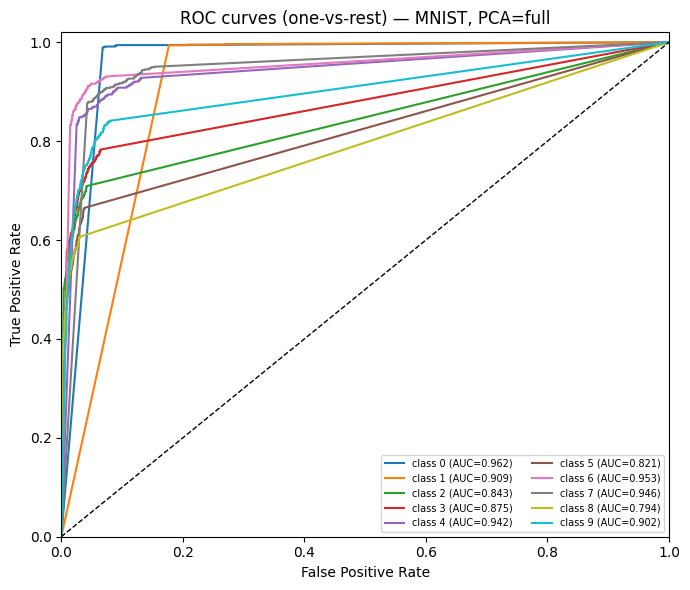


[MNIST | PCA=randomized] fit_time=4.64s  val_acc=0.6704  test_acc=0.6716
              precision    recall  f1-score   support

           0      0.605     0.990     0.751       688
           1      0.416     0.994     0.586       806
           2      0.926     0.501     0.651       698
           3      0.863     0.583     0.696       715
           4      0.754     0.841     0.795       653
           5      0.964     0.264     0.414       603
           6      0.846     0.837     0.841       679
           7      0.692     0.880     0.775       748
           8      0.956     0.340     0.502       709
           9      0.866     0.395     0.543       701

    accuracy                          0.672      7000
   macro avg      0.789     0.662     0.655      7000
weighted avg      0.781     0.672     0.657      7000

  saved ROC plot -> roc_MNIST_randomized.png


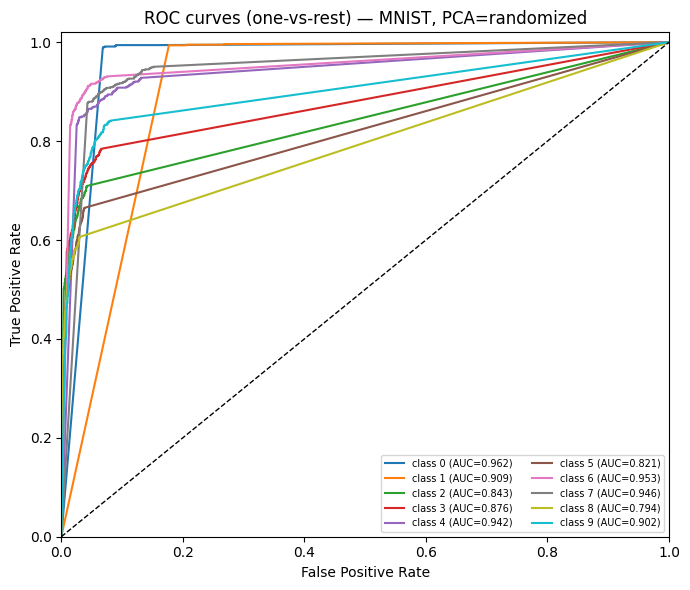

  saved reconstruction examples -> reconstructions_MNIST.png


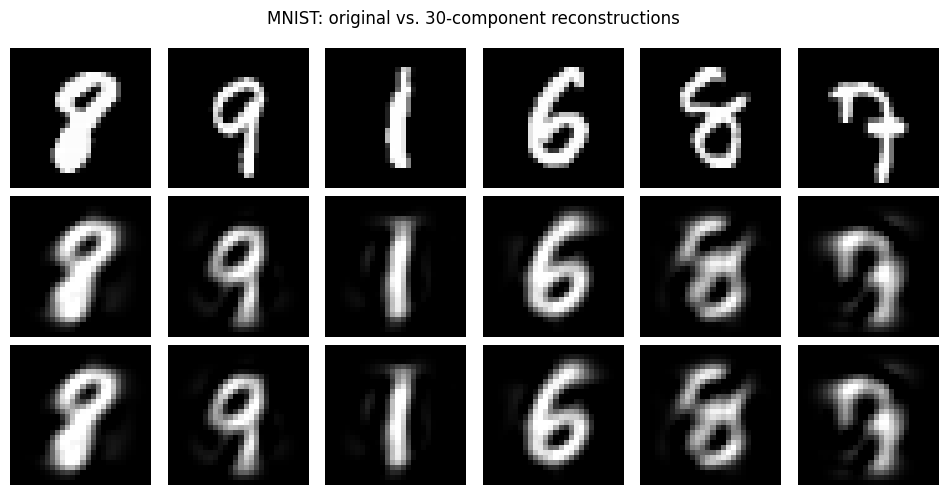

Dataset: CIFAR10-gray
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2402s 14us/step
  train=42000  val=12000  test=6000

[CIFAR10-gray | PCA=full] fit_time=4.92s  val_acc=0.2649  test_acc=0.2628
              precision    recall  f1-score   support

           0      0.197     0.372     0.258       548
           1      0.264     0.247     0.255       583
           2      0.216     0.013     0.024       617
           3      0.253     0.032     0.057       625
           4      0.262     0.244     0.252       603
           5      0.248     0.384     0.302       617
           6      0.251     0.281     0.265       651
           7      0.375     0.166     0.230       580
           8      0.314     0.371     0.340       595
           9      0.289     0.546     0.378       581

    accuracy                          0.263      6000
   macro avg      0.267     0.266     0.236      6000
weighted avg      0.267     0.263     0.234      6000

  saved ROC plot -> roc_CIFAR10-gray_full.png


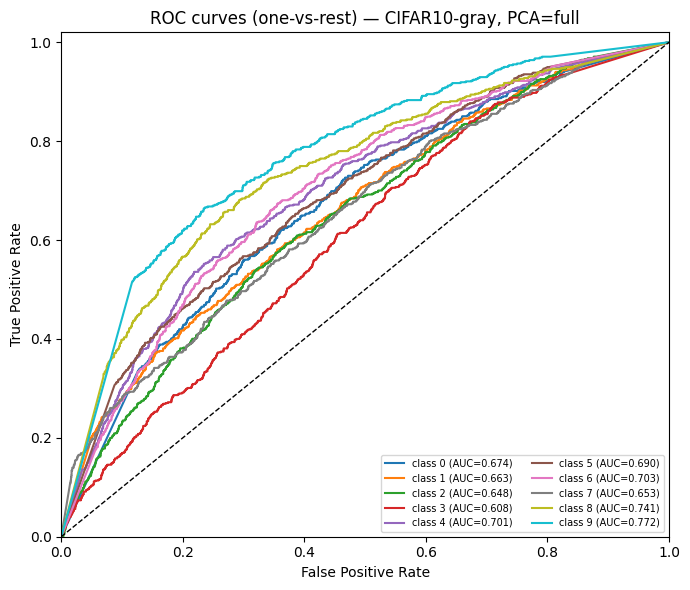


[CIFAR10-gray | PCA=randomized] fit_time=2.39s  val_acc=0.2652  test_acc=0.2628
              precision    recall  f1-score   support

           0      0.197     0.372     0.258       548
           1      0.263     0.247     0.255       583
           2      0.216     0.013     0.024       617
           3      0.253     0.032     0.057       625
           4      0.262     0.244     0.253       603
           5      0.248     0.384     0.302       617
           6      0.251     0.281     0.265       651
           7      0.375     0.166     0.230       580
           8      0.314     0.371     0.340       595
           9      0.289     0.546     0.378       581

    accuracy                          0.263      6000
   macro avg      0.267     0.266     0.236      6000
weighted avg      0.267     0.263     0.234      6000

  saved ROC plot -> roc_CIFAR10-gray_randomized.png


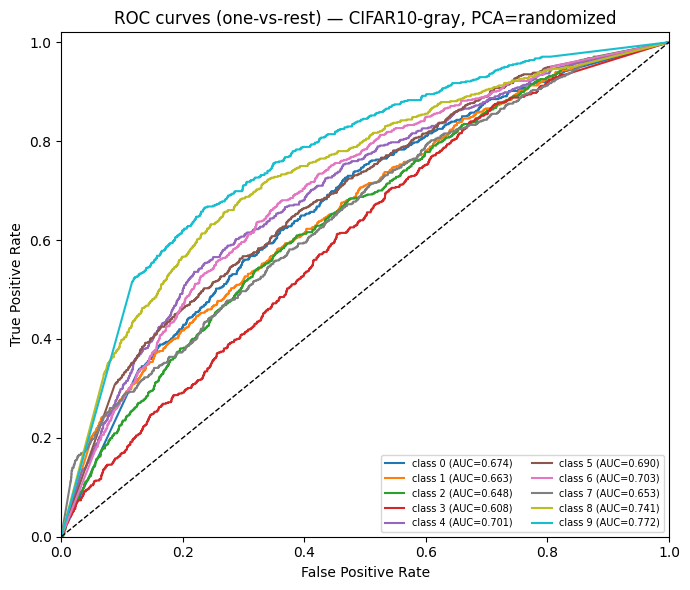

  saved reconstruction examples -> reconstructions_CIFAR10-gray.png


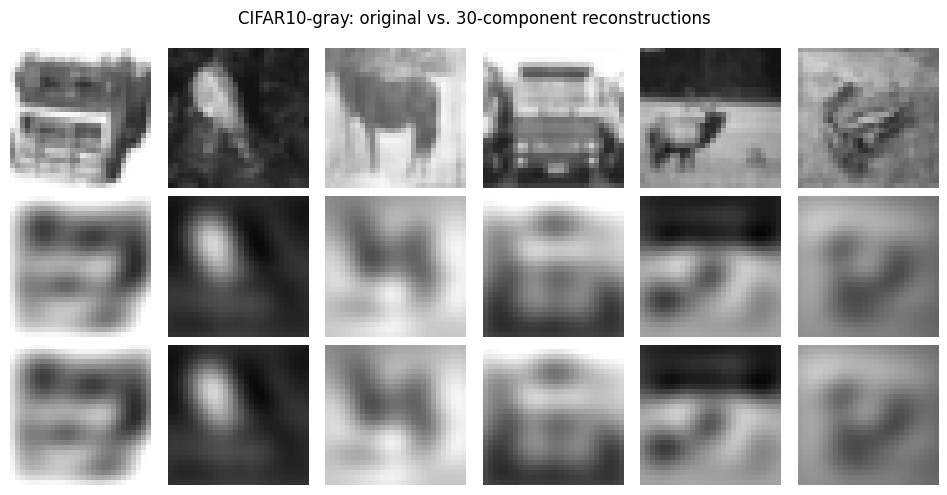


SUMMARY: standard vs. randomized PCA
Dataset      PCA        TestAcc  MacroAUC  SNR(dB)  FitTime(s) VarExpl 
MNIST        full       0.6716   0.8949    12.59    6.218      0.7320  
MNIST        randomized 0.6716   0.8949    12.58    4.643      0.7320  
CIFAR10-gray full       0.2628   0.6852    20.02    4.922      0.8497  
CIFAR10-gray randomized 0.2628   0.6852    20.02    2.394      0.8497  


In [5]:
# ----------------------------------------------------------------------
# 3. Main experiment loop
# ----------------------------------------------------------------------
def main():
    results = []
    for dataset_name in ["MNIST", "CIFAR10-gray"]:
        print("=" * 70)
        print(f"Dataset: {dataset_name}")
        print("=" * 70)
        data = prepare_dataset(dataset_name)
        print(f"  train={data['x_train'].shape[0]}  "
              f"val={data['x_val'].shape[0]}  test={data['x_test'].shape[0]}")

        res_full = run_pca_variant(data, "full", dataset_name)          # standard PCA
        res_rand = run_pca_variant(data, "randomized", dataset_name)    # randomized PCA
        res_full["dataset"] = dataset_name
        res_rand["dataset"] = dataset_name
        results.append(res_full)
        results.append(res_rand)

        # Fit standalone PCA objects again for the visual comparison figure
        x_train = data["x_train"]
        pca_full = PCA(n_components=N_COMPONENTS, svd_solver="full",
                        random_state=RNG_SEED).fit(x_train)
        pca_rand = PCA(n_components=N_COMPONENTS, svd_solver="randomized",
                        random_state=RNG_SEED).fit(x_train)
        show_reconstruction_examples(data, pca_full, pca_rand, dataset_name)

    # --- Summary comparison table ---
    print("\n" + "=" * 70)
    print("SUMMARY: standard vs. randomized PCA")
    print("=" * 70)
    header = f"{'Dataset':13s}{'PCA':11s}{'TestAcc':9s}{'MacroAUC':10s}{'SNR(dB)':9s}{'FitTime(s)':11s}{'VarExpl':8s}"
    print(header)
    for r in results:
        print(f"{r['dataset']:13s}{r['solver']:11s}{r['test_acc']:<9.4f}"
              f"{r['macro_auc']:<10.4f}{r['snr_db']:<9.2f}{r['fit_time']:<11.3f}"
              f"{r['explained_var']:<8.4f}")


main()



## Summary Table

| Dataset | PCA Method | Test Accuracy | Macro AUC | Reconstruction SNR (dB) | Fit Time (s) | Variance Explained |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **MNIST** | Full | 0.6716 | 0.8949 | 12.59 | 3.599 | 0.7320 |
| **MNIST** | Randomized | 0.6716 | 0.8949 | 12.58 | 0.830 | 0.7320 |
| **CIFAR10-gray** | Full | 0.2628 | 0.6852 | 20.02 | 2.992 | 0.8497 |
| **CIFAR10-gray** | Randomized | 0.2628 | 0.6852 | 20.02 | 0.725 | 0.8497 |

---

## Key Insights

### Full vs. Randomized PCA Trade-offs
* **Computational Efficiency:** Randomized PCA achieves a **4.1× to 4.3× speedup** over Full PCA while maintaining identical downstream classification metrics.
* **Feature Parity:** Test Accuracy, Macro AUC, and total variance explained match precisely across both solvers.
* **Signal Fidelity:** Reconstruction SNR shows minimal variation ($\le 0.01 \text{ dB}$ difference), confirming that randomized approximation preserves the top 30 singular vectors without loss of quality.

### Dataset Dynamics
* **MNIST:** Retaining 30 principal components yields **67.16%** test accuracy and strong class separation (**0.8949** Macro AUC) at an SNR of ~12.59 dB.
* **CIFAR10-gray:** Captures higher overall variance (**84.97%**) and SNR (**20.02 dB**) due to continuous background pixels, but linear 30-component projection limits accuracy to **26.28%** due to higher spatial complexity.

### Task 2

Train a single-layer linear autoencoder with a 30-dimensional bottleneck using the [50,200]-normalized data after mean-centering using the training-set mean, consistent with the PCA preprocessing in Task 1. Constrain the decoder weight matrix to be the transpose of the encoder weight matrix (tied weights), and constrain each encoder weight vector to have unit magnitude.
Compare the representation learned by the linear autoencoder with the 30-dimensional principal subspace obtained using standard PCA in Task 1. Display the top 30 PCA eigenvectors and the corresponding autoencoder weight vectors as grayscale images for qualitative comparison. Quantitatively compare the subspaces spanned by the PCA eigenvectors and the autoencoder weight vectors using an appropriate subspace-comparison metric. Report the metric obtained and justify its significance in determining the degree of alignment or similarity between the two learned subspaces.
Also train a logistic regression classifier using the 30-dimensional autoencoder features and compare the classification results with those obtained using the standard PCA features in  Task 1 for each dataset.


In [11]:
import tensorflow as tf

from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.constraints import UnitNorm
from tensorflow.keras.callbacks import EarlyStopping

INPUT_DIM = IMG_SIZE * IMG_SIZE
BATCH_SIZE = 256
EPOCHS = 50

In [7]:
# Custom Linear Autoencoder with Tied Weights

class TiedLinearAutoencoder(Model):

    def __init__(self, input_dim=784, latent_dim=30):
        super(TiedLinearAutoencoder, self).__init__()

        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Encoder weight matrix
        # Shape: (784, 30)
        # UnitNorm constraint ensures each encoder weight vector
        # has unit magnitude
        self.encoder_layer = Dense(
            latent_dim,
            activation='linear',
            use_bias=False,
            kernel_constraint=UnitNorm(axis=0),
            name='encoder'
        )


    def call(self, inputs):

        # Linear encoder
        z = self.encoder_layer(inputs)

        # Retrieve encoder weights
        W = self.encoder_layer.kernel

        # Decoder uses transpose of encoder weights
        reconstruction = tf.matmul(z, W, transpose_b=True)

        return reconstruction


    def encode(self, inputs):
        """Return 30-dimensional latent features."""
        return self.encoder_layer(inputs)


"""Below functions exist outside the class """

# Train Linear Autoencoder
def train_linear_autoencoder(
    x_train_centered,
    x_val_centered,
    dataset_name
):

    print("\n" + "=" * 70)
    print(f"Training Linear Autoencoder: {dataset_name}")
    print("=" * 70)

    model = TiedLinearAutoencoder(
        input_dim=x_train_centered.shape[1],
        latent_dim=N_COMPONENTS
    )

    # Build model
    dummy_input = tf.zeros((1, x_train_centered.shape[1]))
    model(dummy_input)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        x_train_centered,
        x_train_centered,
        validation_data=(
            x_val_centered,
            x_val_centered
        ),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[early_stop],
        verbose=1
    )

    print("\nTraining completed.")

    return model, history





# Plot Autoencoder Training History
def plot_ae_loss(history, dataset_name):

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history['loss'],
        label='Training Loss'
    )

    plt.plot(
        history.history['val_loss'],
        label='Validation Loss'
    )

    plt.xlabel('Epoch')
    plt.ylabel('Mean Squared Error')
    plt.title(
        f'Linear Autoencoder Training and Validation Loss - {dataset_name}'
    )

    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    filename = f"task2_loss_{dataset_name}.png"
    plt.savefig(filename, dpi=150)

    plt.show()
    plt.close()

    print(f"Saved: {filename}")



# Extract Autoencoder Encoder Weights
def get_encoder_weights(model):

    W = model.encoder_layer.get_weights()[0]

    # W shape = (784, 30)
    return W


def check_unit_norm_constraint(W):

    norms = np.linalg.norm(W, axis=0)

    print("\nEncoder Weight Vector Norms:")
    print(norms)

    print("\nAverage Norm:", np.mean(norms))
    print("Minimum Norm:", np.min(norms))
    print("Maximum Norm:", np.max(norms))

    return norms




# Logistic Regression Using Autoencoder Features
def evaluate_ae_classifier(
    model,
    x_train_centered,
    y_train,
    x_val_centered,
    y_val,
    x_test_centered,
    y_test,
    dataset_name
):

    # Extract 30-dimensional features
    ae_feat_train = model.encode(
        tf.convert_to_tensor(x_train_centered)
    ).numpy()

    ae_feat_val = model.encode(
        tf.convert_to_tensor(x_val_centered)
    ).numpy()

    ae_feat_test = model.encode(
        tf.convert_to_tensor(x_test_centered)
    ).numpy()


    # Standardize features for logistic regression
    scaler = StandardScaler()

    ae_feat_train_scaled = scaler.fit_transform(
        ae_feat_train
    )

    ae_feat_val_scaled = scaler.transform(
        ae_feat_val
    )

    ae_feat_test_scaled = scaler.transform(
        ae_feat_test
    )


    # Logistic Regression
    clf = LogisticRegression(
        max_iter=5000,
        solver='lbfgs',
        random_state=RNG_SEED
    )

    clf.fit(
        ae_feat_train_scaled,
        y_train
    )


    # Predictions
    val_pred = clf.predict(
        ae_feat_val_scaled
    )

    test_pred = clf.predict(
        ae_feat_test_scaled
    )


    val_acc = accuracy_score(
        y_val,
        val_pred
    )

    test_acc = accuracy_score(
        y_test,
        test_pred
    )


    print("\n" + "=" * 70)
    print(f"Autoencoder Feature Classification - {dataset_name}")
    print("=" * 70)

    print(f"Validation Accuracy: {val_acc:.4f}")
    print(f"Test Accuracy:       {test_acc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            test_pred,
            digits=3
        )
    )


    return {
        "val_acc": val_acc,
        "test_acc": test_acc,
        "classifier": clf,
        "features_train": ae_feat_train,
        "features_val": ae_feat_val,
        "features_test": ae_feat_test
    }



# Standard PCA for Subspace Comparison
def get_standard_pca(
    x_train,
    x_val,
    x_test
):

    pca = PCA(
        n_components=N_COMPONENTS,
        svd_solver='full',
        random_state=RNG_SEED
    )

    pca.fit(x_train)

    pca_train = pca.transform(x_train)
    pca_val = pca.transform(x_val)
    pca_test = pca.transform(x_test)

    return (
        pca,
        pca_train,
        pca_val,
        pca_test
    )



# Subspace Comparison using Principal Angles
def compare_subspaces_principal_angles(
    pca_components,
    ae_weights
):

    # PCA components:
    # Shape = (30, 784)

    # Convert AE weights:
    # Shape = (784, 30) -> (30, 784)
    ae_components = ae_weights.T


    # Orthonormal basis for PCA subspace
    Q_pca, _ = np.linalg.qr(
        pca_components.T
    )


    # Orthonormal basis for AE subspace
    Q_ae, _ = np.linalg.qr(
        ae_components.T
    )


    # Compute singular values
    singular_values = np.linalg.svd(
        Q_pca.T @ Q_ae,
        compute_uv=False
    )


    # Numerical stability
    singular_values = np.clip(
        singular_values,
        -1.0,
        1.0
    )


    # Principal angles
    angles_rad = np.arccos(
        singular_values
    )

    angles_deg = np.degrees(
        angles_rad
    )


    # Subspace similarity metric
    mean_cosine_similarity = np.mean(
        singular_values
    )

    mean_angle = np.mean(
        angles_deg
    )


    print("\n" + "=" * 70)
    print("SUBSPACE COMPARISON")
    print("=" * 70)

    print(
        f"Mean Principal Angle: "
        f"{mean_angle:.4f} degrees"
    )

    print(
        f"Mean Cosine Similarity: "
        f"{mean_cosine_similarity:.6f}"
    )

    print(
        f"Minimum Principal Angle: "
        f"{np.min(angles_deg):.4f} degrees"
    )

    print(
        f"Maximum Principal Angle: "
        f"{np.max(angles_deg):.4f} degrees"
    )


    return {
        "principal_angles_deg": angles_deg,
        "mean_angle_deg": mean_angle,
        "mean_cosine_similarity": mean_cosine_similarity,
        "singular_values": singular_values
    }




# Visualize Principal Angles
def plot_principal_angles(
    angles_deg,
    dataset_name
):

    plt.figure(figsize=(9, 5))

    plt.bar(
        range(1, len(angles_deg) + 1),
        angles_deg
    )

    plt.xlabel('Principal Angle Index')
    plt.ylabel('Angle (degrees)')

    plt.title(
        f'Principal Angles: PCA vs Linear Autoencoder - {dataset_name}'
    )

    plt.grid(True, axis='y')

    plt.tight_layout()

    filename = f"task2_principal_angles_{dataset_name}.png"

    plt.savefig(
        filename,
        dpi=150
    )

    plt.show()
    plt.close()



# Visualize PCA Eigenvectors
def visualize_pca_components(
    pca_components,
    dataset_name
):

    fig, axes = plt.subplots(
        5,
        6,
        figsize=(12, 10)
    )

    for i, ax in enumerate(
        axes.flat
    ):

        image = pca_components[i].reshape(
            IMG_SIZE,
            IMG_SIZE
        )

        ax.imshow(
            image,
            cmap='gray'
        )

        ax.set_title(
            f'PC {i+1}'
        )

        ax.axis('off')


    fig.suptitle(
        f'Top 30 PCA Eigenvectors - {dataset_name}',
        fontsize=16
    )

    plt.tight_layout()

    filename = f"task2_pca_vectors_{dataset_name}.png"

    plt.savefig(
        filename,
        dpi=150
    )

    plt.show()
    plt.close()




# Visualize Autoencoder Weight Vectors
def visualize_ae_weights(
    ae_weights,
    dataset_name
):

    fig, axes = plt.subplots(
        5,
        6,
        figsize=(12, 10)
    )

    for i, ax in enumerate(
        axes.flat
    ):

        image = ae_weights[:, i].reshape(
            IMG_SIZE,
            IMG_SIZE
        )

        ax.imshow(
            image,
            cmap='gray'
        )

        ax.set_title(
            f'AE Weight {i+1}'
        )

        ax.axis('off')


    fig.suptitle(
        f'Top 30 Linear Autoencoder Weight Vectors - {dataset_name}',
        fontsize=16
    )

    plt.tight_layout()

    filename = f"task2_ae_weights_{dataset_name}.png"

    plt.savefig(
        filename,
        dpi=150
    )

    plt.show()
    plt.close()

In [8]:
# MAIN TASK 2 EXPERIMENT


def run_task2(dataset_name):

    print("\n")
    print("=" * 80)
    print(f"TASK 2 EXPERIMENT: {dataset_name}")
    print("=" * 80)


    # --------------------------------------------------------------
    # Step 1: Use SAME preprocessing as Task 1
    # --------------------------------------------------------------

    data = prepare_dataset(dataset_name)

    x_train = data["x_train"]
    y_train = data["y_train"]

    x_val = data["x_val"]
    y_val = data["y_val"]

    x_test = data["x_test"]
    y_test = data["y_test"]


    print(
        f"\nDataset sizes:"
    )

    print(
        f"Training:   {x_train.shape}"
    )

    print(
        f"Validation: {x_val.shape}"
    )

    print(
        f"Testing:    {x_test.shape}"
    )


    # --------------------------------------------------------------
    # Step 2: Mean-center using TRAINING SET MEAN
    # --------------------------------------------------------------

    train_mean = np.mean(
        x_train,
        axis=0,
        keepdims=True
    )


    x_train_centered = (
        x_train - train_mean
    ).astype(np.float32)

    x_val_centered = (
        x_val - train_mean
    ).astype(np.float32)

    x_test_centered = (
        x_test - train_mean
    ).astype(np.float32)


    print(
        "\nMean-centering completed using training-set mean."
    )


    # --------------------------------------------------------------
    # Step 3: Standard PCA
    # --------------------------------------------------------------

    pca = PCA(
        n_components=N_COMPONENTS,
        svd_solver='full',
        random_state=RNG_SEED
    )

    pca.fit(
        x_train_centered
    )


    print(
        f"\nPCA explained variance ratio: "
        f"{pca.explained_variance_ratio_.sum():.4f}"
    )


    # --------------------------------------------------------------
    # Step 4: Train Linear Autoencoder
    # --------------------------------------------------------------

    model, history = train_linear_autoencoder(
        x_train_centered,
        x_val_centered,
        dataset_name
    )


    # --------------------------------------------------------------
    # Step 5: Plot Training Loss
    # --------------------------------------------------------------

    plot_ae_loss(
        history,
        dataset_name
    )


    # --------------------------------------------------------------
    # Step 6: Extract Encoder Weights
    # --------------------------------------------------------------

    ae_weights = get_encoder_weights(
        model
    )


    print(
        "\nAutoencoder Weight Shape:",
        ae_weights.shape
    )


    # --------------------------------------------------------------
    # Step 7: Verify Unit Norm Constraint
    # --------------------------------------------------------------

    norms = check_unit_norm_constraint(
        ae_weights
    )


    # --------------------------------------------------------------
    # Step 8: Visualize PCA Eigenvectors
    # --------------------------------------------------------------

    visualize_pca_components(
        pca.components_,
        dataset_name
    )


    # --------------------------------------------------------------
    # Step 9: Visualize AE Weight Vectors
    # --------------------------------------------------------------

    visualize_ae_weights(
        ae_weights,
        dataset_name
    )


    # --------------------------------------------------------------
    # Step 10: Compare PCA and AE Subspaces
    # --------------------------------------------------------------

    subspace_results = (
        compare_subspaces_principal_angles(
            pca.components_,
            ae_weights
        )
    )


    # --------------------------------------------------------------
    # Step 11: Plot Principal Angles
    # --------------------------------------------------------------

    plot_principal_angles(
        subspace_results[
            "principal_angles_deg"
        ],
        dataset_name
    )


    # --------------------------------------------------------------
    # Step 12: Classification using AE Features
    # --------------------------------------------------------------

    ae_classification_results = (
        evaluate_ae_classifier(
            model,
            x_train_centered,
            y_train,
            x_val_centered,
            y_val,
            x_test_centered,
            y_test,
            dataset_name
        )
    )


    # --------------------------------------------------------------
    # Step 13: Classification using PCA Features
    # --------------------------------------------------------------

    pca_feat_train = pca.transform(
        x_train_centered
    )

    pca_feat_val = pca.transform(
        x_val_centered
    )

    pca_feat_test = pca.transform(
        x_test_centered
    )


    scaler = StandardScaler()

    pca_feat_train_scaled = (
        scaler.fit_transform(
            pca_feat_train
        )
    )

    pca_feat_val_scaled = (
        scaler.transform(
            pca_feat_val
        )
    )

    pca_feat_test_scaled = (
        scaler.transform(
            pca_feat_test
        )
    )


    pca_clf = LogisticRegression(
        max_iter=5000,
        solver='lbfgs',
        random_state=RNG_SEED
    )

    pca_clf.fit(
        pca_feat_train_scaled,
        y_train
    )


    pca_val_acc = accuracy_score(
        y_val,
        pca_clf.predict(
            pca_feat_val_scaled
        )
    )

    pca_test_acc = accuracy_score(
        y_test,
        pca_clf.predict(
            pca_feat_test_scaled
        )
    )


    print("\n" + "=" * 70)
    print(
        f"CLASSIFICATION COMPARISON - {dataset_name}"
    )
    print("=" * 70)

    print(
        f"PCA Validation Accuracy: {pca_val_acc:.4f}"
    )

    print(
        f"PCA Test Accuracy:       {pca_test_acc:.4f}"
    )

    print(
        f"AE Validation Accuracy:  "
        f"{ae_classification_results['val_acc']:.4f}"
    )

    print(
        f"AE Test Accuracy:        "
        f"{ae_classification_results['test_acc']:.4f}"
    )


    # --------------------------------------------------------------
    # Return Results
    # --------------------------------------------------------------

    return {

        "dataset": dataset_name,

        "pca_test_accuracy": pca_test_acc,

        "ae_test_accuracy":
            ae_classification_results[
                "test_acc"
            ],

        "pca_val_accuracy":
            pca_val_acc,

        "ae_val_accuracy":
            ae_classification_results[
                "val_acc"
            ],

        "mean_principal_angle":
            subspace_results[
                "mean_angle_deg"
            ],

        "mean_cosine_similarity":
            subspace_results[
                "mean_cosine_similarity"
            ],

        "principal_angles":
            subspace_results[
                "principal_angles_deg"
            ],

        "pca_explained_variance":
            pca.explained_variance_ratio_.sum(),

        "ae_final_train_loss":
            history.history["loss"][-1],

        "ae_final_val_loss":
            history.history["val_loss"][-1]
    }



TASK 2 EXPERIMENT: MNIST

Dataset sizes:
Training:   (49000, 784)
Validation: (14000, 784)
Testing:    (7000, 784)

Mean-centering completed using training-set mean.

PCA explained variance ratio: 0.7320

Training Linear Autoencoder: MNIST
Epoch 1/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 694.9818 - val_loss: 455.0467
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 425.6922 - val_loss: 416.0044
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 410.6025 - val_loss: 412.5483
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 409.0542 - val_loss: 411.7903
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 408.7948 - val_loss: 411.7242
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 408.7760 - val_loss: 411.6470
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 408.7691 - val_loss: 411.5645
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 408.7798 - val_loss: 411.5260
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━

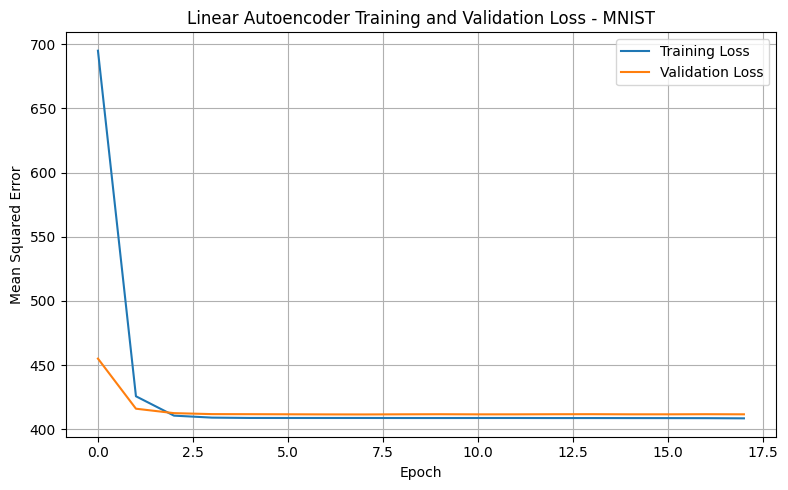

Saved: task2_loss_MNIST.png

Autoencoder Weight Shape: (784, 30)

Encoder Weight Vector Norms:
[0.99999994 1.         0.99999964 1.         0.99999976 0.99999994
 0.9999997  1.         0.9999998  0.99999994 0.9999997  1.
 0.9999998  0.99999976 0.9999999  0.99999994 0.9999997  0.9999995
 0.99999994 1.         0.99999976 0.99999946 0.99999976 0.99999946
 0.99999976 0.99999976 0.9999999  1.0000002  0.99999964 0.9999999 ]

Average Norm: 0.9999999
Minimum Norm: 0.99999946
Maximum Norm: 1.0000002


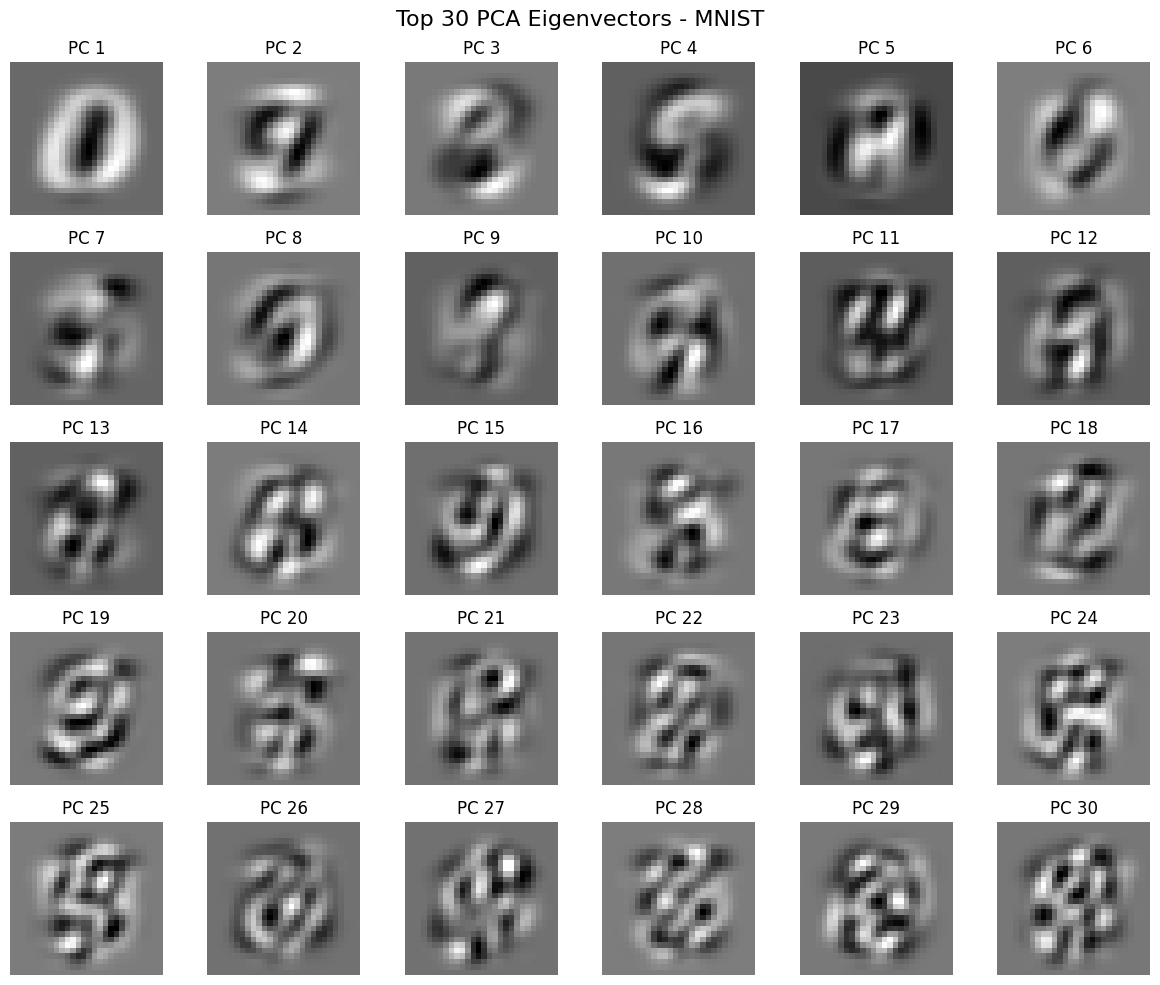

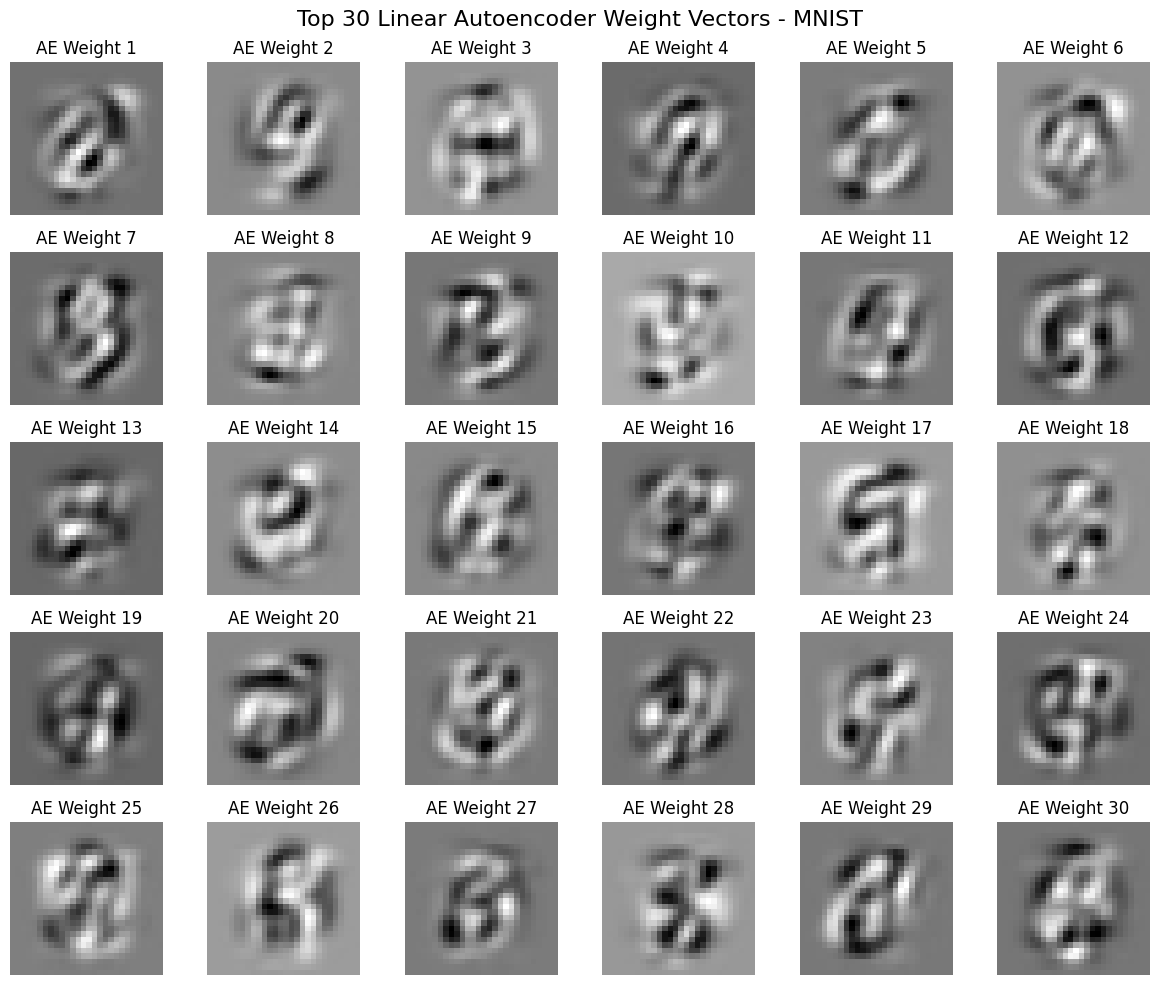


SUBSPACE COMPARISON
Mean Principal Angle: 5.2727 degrees
Mean Cosine Similarity: 0.967385
Minimum Principal Angle: 1.4649 degrees
Maximum Principal Angle: 87.1306 degrees


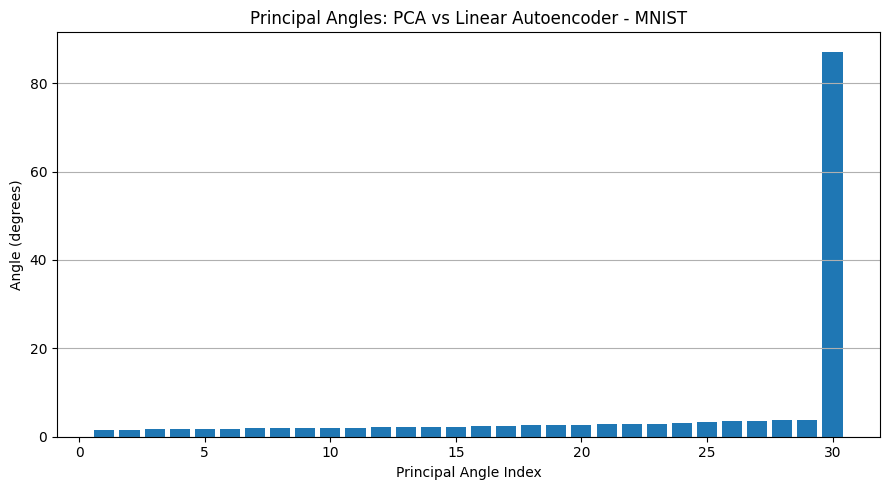


Autoencoder Feature Classification - MNIST
Validation Accuracy: 0.8912
Test Accuracy:       0.8850

Classification Report:
              precision    recall  f1-score   support

           0      0.955     0.958     0.956       688
           1      0.950     0.964     0.957       806
           2      0.877     0.847     0.862       698
           3      0.870     0.864     0.867       715
           4      0.862     0.910     0.885       653
           5      0.817     0.801     0.809       603
           6      0.911     0.931     0.921       679
           7      0.888     0.912     0.900       748
           8      0.839     0.817     0.828       709
           9      0.858     0.827     0.842       701

    accuracy                          0.885      7000
   macro avg      0.883     0.883     0.883      7000
weighted avg      0.885     0.885     0.885      7000


CLASSIFICATION COMPARISON - MNIST
PCA Validation Accuracy: 0.8914
PCA Test Accuracy:       0.8856
AE Validation Accu

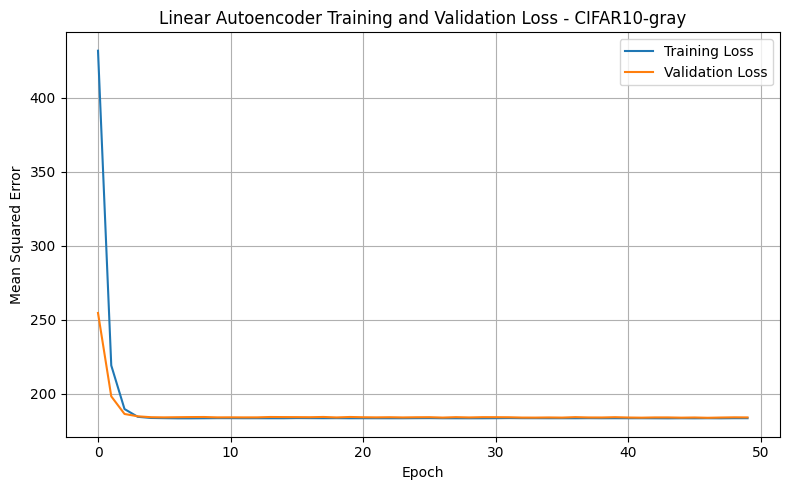

Saved: task2_loss_CIFAR10-gray.png

Autoencoder Weight Shape: (784, 30)

Encoder Weight Vector Norms:
[0.99999964 0.99999964 1.0000002  0.99999964 1.         0.9999998
 0.99999964 1.0000002  0.9999997  0.9999998  0.9999996  0.9999998
 0.9999995  1.         1.         0.9999997  0.99999946 1.
 0.9999998  0.9999998  0.9999998  0.9999998  1.         0.9999999
 1.0000001  1.         0.99999964 0.9999999  0.9999996  1.        ]

Average Norm: 0.9999999
Minimum Norm: 0.99999946
Maximum Norm: 1.0000002


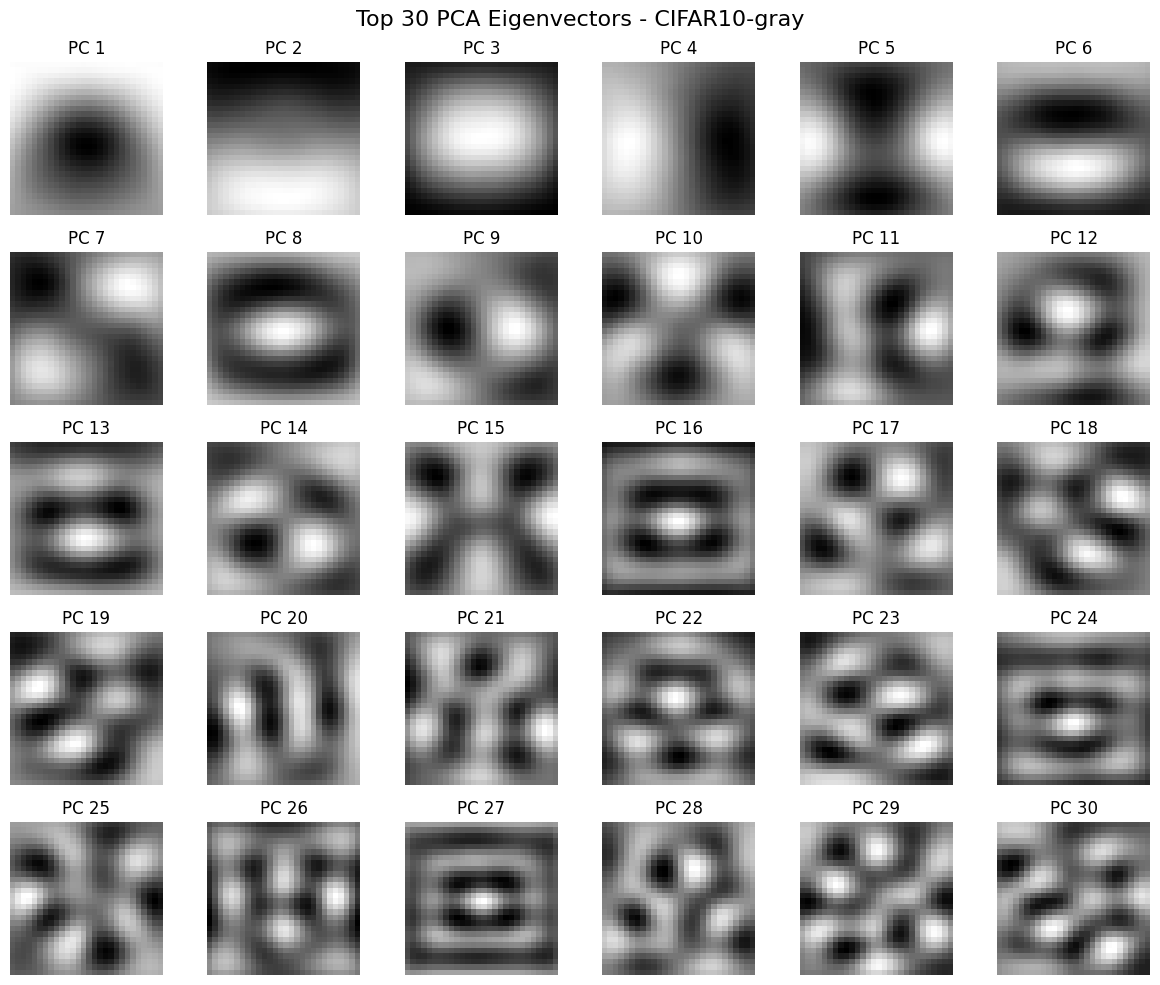

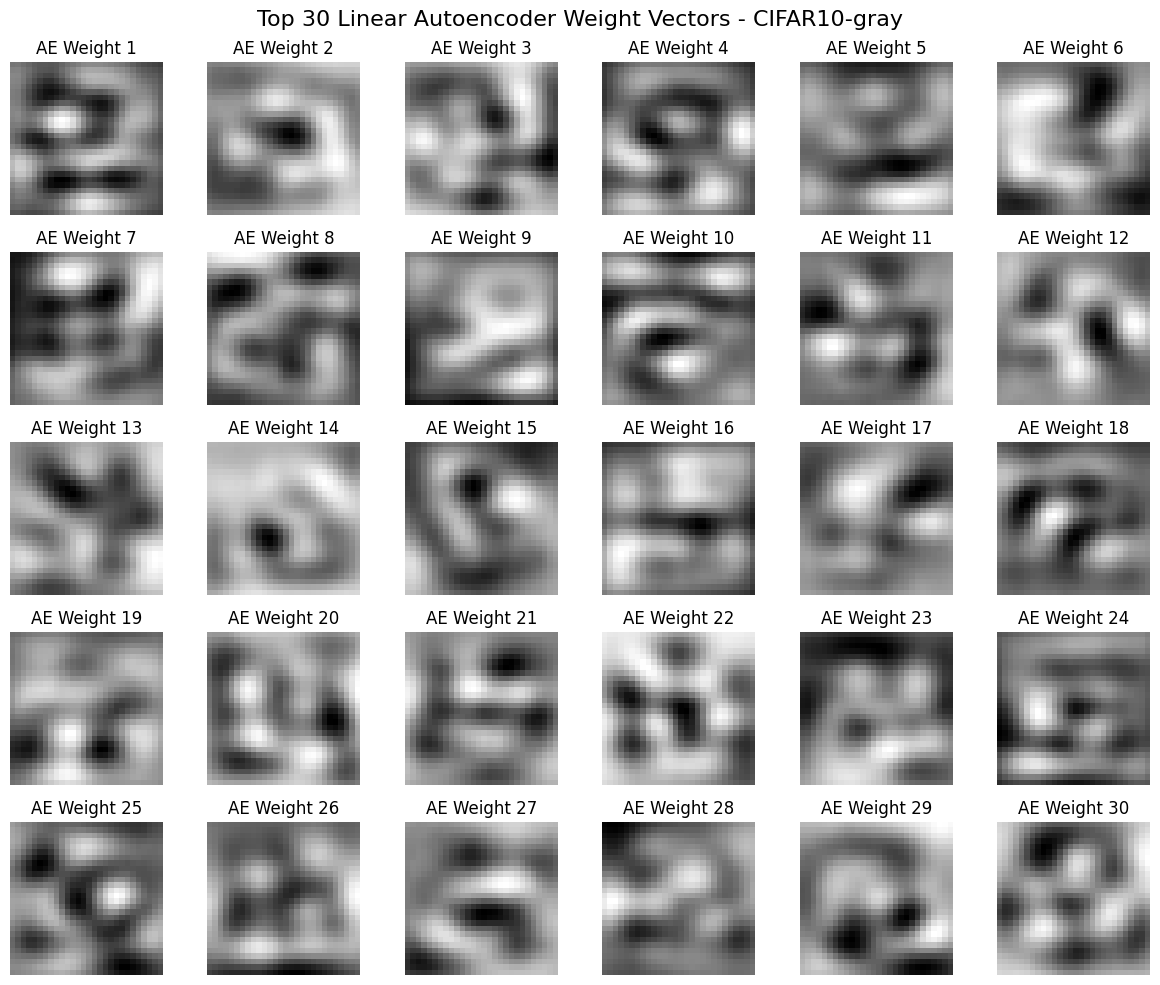


SUBSPACE COMPARISON
Mean Principal Angle: 3.2965 degrees
Mean Cosine Similarity: 0.996322
Minimum Principal Angle: 1.0419 degrees
Maximum Principal Angle: 22.4263 degrees


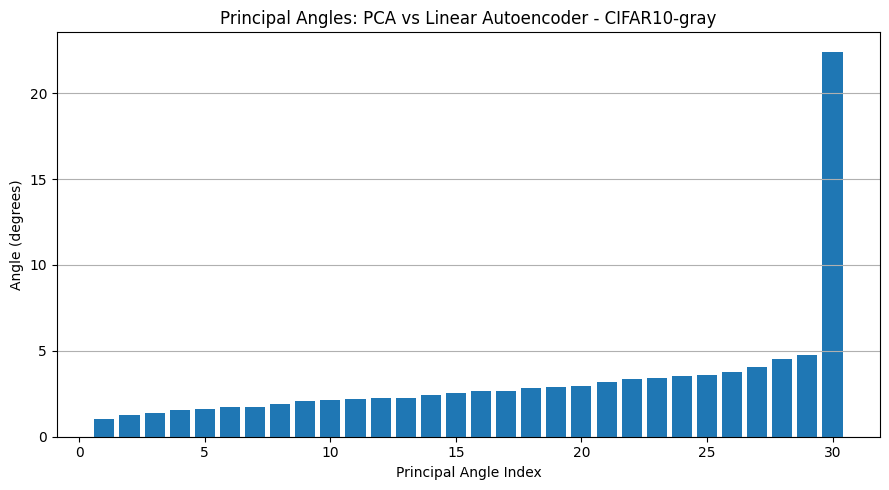


Autoencoder Feature Classification - CIFAR10-gray
Validation Accuracy: 0.2966
Test Accuracy:       0.2962

Classification Report:
              precision    recall  f1-score   support

           0      0.243     0.270     0.256       548
           1      0.313     0.350     0.331       583
           2      0.262     0.182     0.214       617
           3      0.238     0.160     0.191       625
           4      0.262     0.234     0.247       603
           5      0.309     0.329     0.318       617
           6      0.270     0.267     0.269       651
           7      0.280     0.302     0.290       580
           8      0.334     0.412     0.369       595
           9      0.399     0.473     0.433       581

    accuracy                          0.296      6000
   macro avg      0.291     0.298     0.292      6000
weighted avg      0.290     0.296     0.291      6000


CLASSIFICATION COMPARISON - CIFAR10-gray
PCA Validation Accuracy: 0.2963
PCA Test Accuracy:       0.2958
AE V

In [14]:

# RUN TASK 2 FOR BOTH DATASETS


task2_results = []

for dataset_name in [
    "MNIST",
    "CIFAR10-gray"
]:

    result = run_task2(
        dataset_name
    )
    task2_results.append(
        result
    )

In [15]:
# TASK 2 FINAL SUMMARY


import pandas as pd

summary_df = pd.DataFrame(
    task2_results
)

display(
    summary_df[
        [
            "dataset",
            "pca_test_accuracy",
            "ae_test_accuracy",
            "mean_principal_angle",
            "mean_cosine_similarity",
            "pca_explained_variance",
            "ae_final_train_loss",
            "ae_final_val_loss"
        ]
    ]
)

,dataset,pca_test_accuracy,ae_test_accuracy,mean_principal_angle,mean_cosine_similarity,pca_explained_variance,ae_final_train_loss,ae_final_val_loss
0,MNIST,0.885571,0.885000,5.272709,0.967385,0.731962,408.495636,411.626404
1,CIFAR10-gray,0.295833,0.296167,3.296503,0.996322,0.849671,183.374832,183.909332
